# LSTM Forecasting Tryout
Just use btc_cleaned.csv

In [82]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../src'))

# DI
from src.di.container import AppContainer
container = AppContainer()

# use cases for LSTM
data_loader = container.data_loader()
train_lstm_usecase = container.train_lstm_usecase()
evaluate_models_usecase = container.evaluate_models_usecase()

## Load 

In [83]:
data_path = '../data/btc_cleaned.csv'
df = pd.read_csv(data_path)
df['Date'] = pd.to_datetime(df['Date'])

## Train and Predict with LSTM 

In [ ]:
# split
train_df, val_df, test_df = data_loader.split_data(df, train_ratio=0.7, val_ratio=0.15)

# prediction
lstm_preds = train_lstm_usecase.train_and_predict(
    train_series=train_df['Close'],
    test_series=test_df['Close'],
    epochs=20
)

# had no luck with GPU enabling, may be MAC env

2026-07-31 23:39:07,898 | INFO     | [ML_CW_Q2] Converting pandas Series to Darts TimeSeries
2026-07-31 23:39:07,902 | INFO     | [ML_CW_Q2] Initializing and training Darts RNNModel (LSTM)...


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/.venv/lib/python3.9/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 1.8 K  | train
6 | V               | Linear           | 21     | train
-------------------------------------------------------------
1.9 K     Trainable params
0         Non-trainable params
1.9 K     Total params
0.007     Total

2026-07-31 23:39:11,834 | INFO     | [ML_CW_Q2] Generating forecasts using fitted model...


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## Evaluation Metrics

In [85]:
y_true = test_df['Close'].values
metrics = evaluate_models_usecase.calculate_metrics(y_true, lstm_preds.values)
print(f"  MAE :  ${metrics['MAE']:.2f}")
print(f"  RMSE : ${metrics['RMSE']:.2f}")
print(f"  MAPE : {metrics['MAPE']:.2f}%")

  MAE :  $27637.73
  RMSE : $33664.41
  MAPE : 27.28%


## Visualization
Plot the actual Bitcoin prices alongside predictions from the LSTM model.

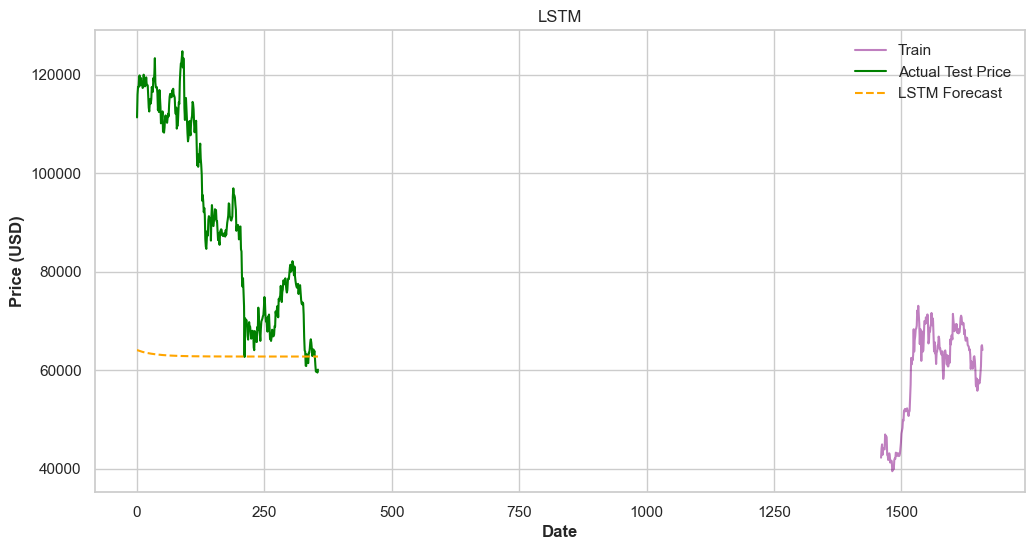

In [86]:
plt.figure(figsize=(12, 6))
plt.plot(train_df['Close'].iloc[-200:], label='Train', color='purple', alpha=0.5)
plt.plot(test_df.index, test_df['Close'], label='Actual Test Price', color='green')
plt.plot(test_df.index, lstm_preds, label='LSTM Forecast', color='orange', linestyle='--')
plt.title('LSTM')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()